In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import sqlite3

df = pd.read_csv('../data/data.csv', encoding='ISO-8859-1')
df = df.dropna(subset=['CustomerID', 'Description'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [2]:
# Extract month period from InvoiceDate
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Group by month, sum revenue
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

print(monthly_revenue)

      Month      Revenue
0   2010-12   572713.890
1   2011-01   569445.040
2   2011-02   447137.350
3   2011-03   595500.760
4   2011-04   469200.361
5   2011-05   678594.560
6   2011-06   661213.690
7   2011-07   600091.011
8   2011-08   645343.900
9   2011-09   952838.382
10  2011-10  1039318.790
11  2011-11  1161817.380
12  2011-12   518192.790


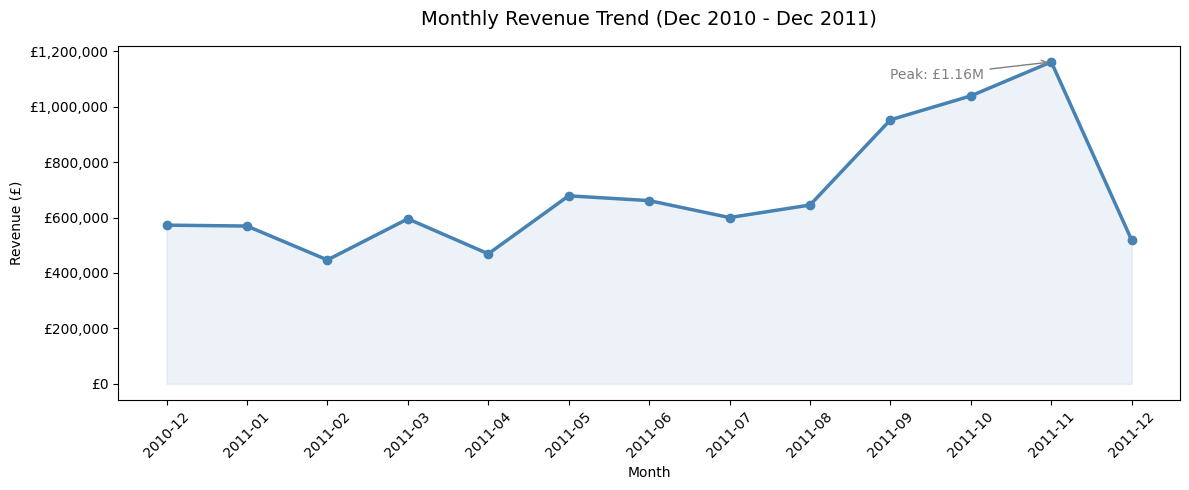

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_revenue['Month'], monthly_revenue['Revenue'], 
        marker='o', linewidth=2.5, color='steelblue', markersize=6)

ax.fill_between(monthly_revenue['Month'], monthly_revenue['Revenue'], 
                alpha=0.1, color='steelblue')

# Formatting
ax.set_title('Monthly Revenue Trend (Dec 2010 - Dec 2011)', fontsize=14, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Annotate peak
peak_idx = monthly_revenue['Revenue'].idxmax()
ax.annotate('Peak: £1.16M', 
            xy=(peak_idx, monthly_revenue['Revenue'][peak_idx]),
            xytext=(peak_idx - 2, 1100000),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('../visuals/monthly_revenue.png', dpi=150)
plt.show()

In [4]:
top_products = (df.groupby('Description')['Revenue']
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())

print(top_products)

                          Description    Revenue
0         PAPER CRAFT , LITTLE BIRDIE  168469.60
1            REGENCY CAKESTAND 3 TIER  142592.95
2  WHITE HANGING HEART T-LIGHT HOLDER  100448.15
3             JUMBO BAG RED RETROSPOT   85220.78
4      MEDIUM CERAMIC TOP STORAGE JAR   81416.73
5                             POSTAGE   77803.96
6                       PARTY BUNTING   68844.33
7       ASSORTED COLOUR BIRD ORNAMENT   56580.34
8                              Manual   53779.93
9                  RABBIT NIGHT LIGHT   51346.20


In [5]:
# Filter out non-product entries
exclude = ['POSTAGE', 'Manual', 'AMAZONFEE', 'Bank Charges', 'CRUK Commission']

top_products = (df[~df['Description'].isin(exclude)]
                .groupby('Description')['Revenue']
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())

print(top_products)

                          Description    Revenue
0         PAPER CRAFT , LITTLE BIRDIE  168469.60
1            REGENCY CAKESTAND 3 TIER  142592.95
2  WHITE HANGING HEART T-LIGHT HOLDER  100448.15
3             JUMBO BAG RED RETROSPOT   85220.78
4      MEDIUM CERAMIC TOP STORAGE JAR   81416.73
5                       PARTY BUNTING   68844.33
6       ASSORTED COLOUR BIRD ORNAMENT   56580.34
7                  RABBIT NIGHT LIGHT   51346.20
8                       CHILLI LIGHTS   46286.51
9     PAPER CHAIN KIT 50'S CHRISTMAS    42660.83


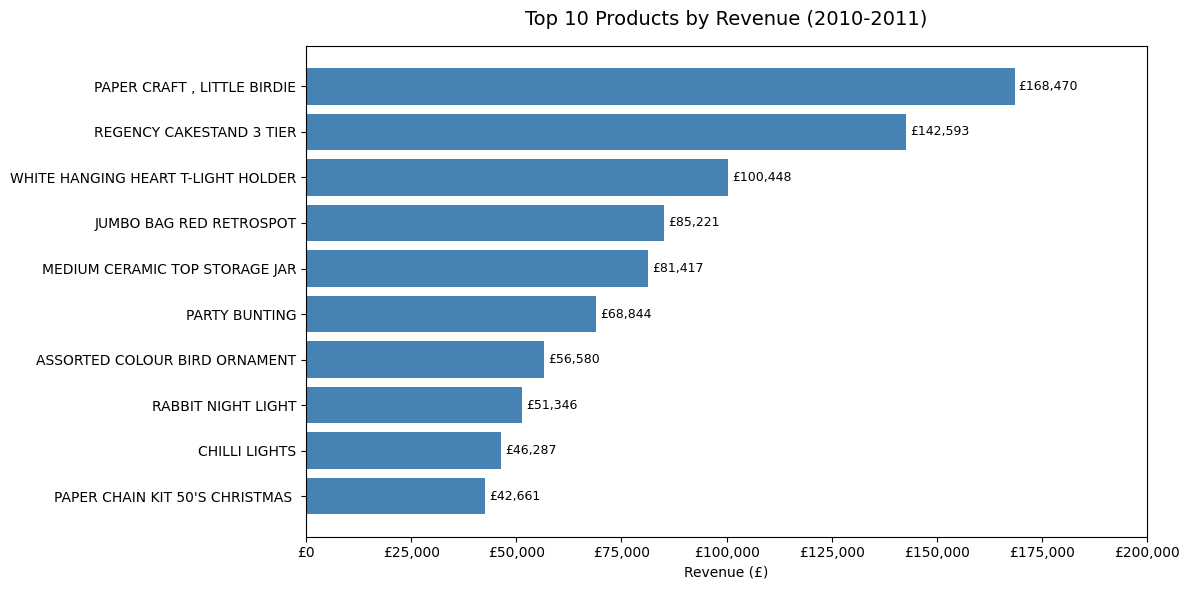

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(top_products['Description'][::-1], 
               top_products['Revenue'][::-1],
               color='steelblue', edgecolor='none')

# Add value labels on bars
for bar, val in zip(bars, top_products['Revenue'][::-1]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 Products by Revenue (2010-2011)', fontsize=14, pad=15)
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_xlim(0, 200000)

plt.tight_layout()
plt.savefig('../visuals/top_products.png', dpi=150)
plt.show()

In [7]:
import datetime

# Reference date -- one day after last transaction
snapshot_date = df['InvoiceDate'].max() + datetime.timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print(rfm.shape)
print(rfm.describe())

(4338, 4)
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000


In [8]:
# Score each metric into quartiles (1-4)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1])  # lower recency = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head(10))

   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0       12346      326          1  77183.60       1       1       4       114
1       12347        2          7   4310.00       4       4       4       444
2       12348       75          4   1797.24       2       3       4       234
3       12349       19          1   1757.55       3       1       4       314
4       12350      310          1    334.40       1       1       2       112
5       12352       36          8   2506.04       3       4       4       344
6       12353      204          1     89.00       1       1       1       111
7       12354      232          1   1079.40       1       1       3       113
8       12355      214          1    459.40       1       1       2       112
9       12356       23          3   2811.43       3       3       4       334


In [9]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalist'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())

Segment
Lost                  1421
Loyal                  914
Champion               609
At Risk                465
Potential Loyalist     431
Cant Lose Them         264
New Customer           234
Name: count, dtype: int64


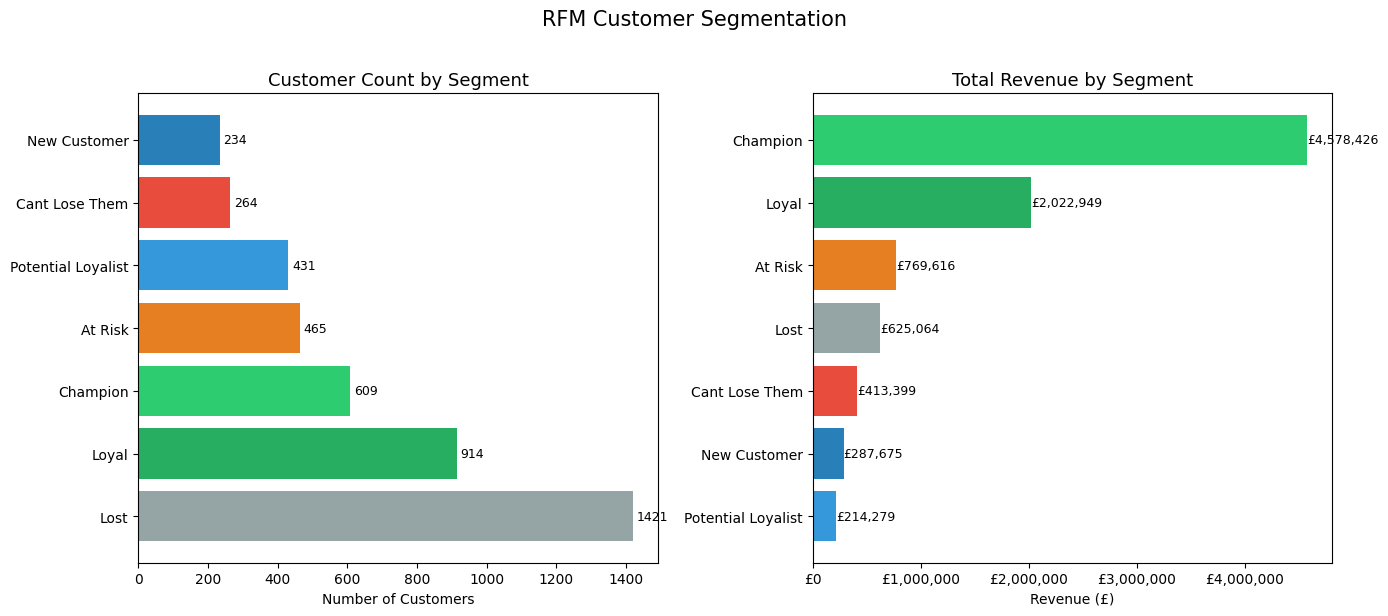

In [10]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

colors = {
    'Champion':          '#2ecc71',
    'Loyal':             '#27ae60',
    'Potential Loyalist':'#3498db',
    'New Customer':      '#2980b9',
    'At Risk':           '#e67e22',
    'Cant Lose Them':    '#e74c3c',
    'Lost':              '#95a5a6'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left -- segment size
bar_colors = [colors[s] for s in segment_counts['Segment']]
axes[0].barh(segment_counts['Segment'], segment_counts['Count'], 
             color=bar_colors, edgecolor='none')
axes[0].set_title('Customer Count by Segment', fontsize=13)
axes[0].set_xlabel('Number of Customers')
for i, val in enumerate(segment_counts['Count']):
    axes[0].text(val + 10, i, str(val), va='center', fontsize=9)

# Right -- revenue by segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().reset_index()
segment_revenue = segment_revenue.sort_values('Monetary', ascending=True)
rev_colors = [colors[s] for s in segment_revenue['Segment']]
axes[1].barh(segment_revenue['Segment'], segment_revenue['Monetary'],
             color=rev_colors, edgecolor='none')
axes[1].set_title('Total Revenue by Segment', fontsize=13)
axes[1].set_xlabel('Revenue (£)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for i, val in enumerate(segment_revenue['Monetary']):
    axes[1].text(val + 1000, i, f'£{val:,.0f}', va='center', fontsize=9)

plt.suptitle('RFM Customer Segmentation', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../visuals/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
import sqlite3

conn = sqlite3.connect('../data/ecommerce.db')

# Write to DB -- drop Month column (Period type unsupported by SQLite)
df_sql = df.drop(columns=['Month'])
df_sql.to_sql('transactions', conn, if_exists='replace', index=False)

def run_query(sql):
    return pd.read_sql_query(sql, conn)

print("DB ready, row count:", run_query("SELECT COUNT(*) FROM transactions").iloc[0,0])

DB ready, row count: 397884


In [12]:
q1 = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS Month,
    ROUND(SUM(Revenue), 2)         AS Total_Revenue,
    COUNT(DISTINCT InvoiceNo)      AS Total_Orders
FROM transactions
GROUP BY Month
ORDER BY Month;
"""

run_query(q1)

,Month,Total_Revenue,Total_Orders
0,2010-12,572713.89,1400
1,2011-01,569445.04,987
2,2011-02,447137.35,997
3,2011-03,595500.76,1321
4,2011-04,469200.36,1149
5,2011-05,678594.56,1555
6,2011-06,661213.69,1393
7,2011-07,600091.01,1331
8,2011-08,645343.90,1280
9,2011-09,952838.38,1755


In [13]:
q2 = """
SELECT 
    Description,
    ROUND(SUM(Revenue), 2)    AS Total_Revenue,
    SUM(Quantity)             AS Total_Units_Sold,
    COUNT(DISTINCT InvoiceNo) AS Total_Orders
FROM transactions
WHERE Description NOT IN ('POSTAGE', 'Manual', 'AMAZONFEE', 'Bank Charges', 'CRUK Commission')
GROUP BY Description
ORDER BY Total_Revenue DESC
LIMIT 10;
"""

run_query(q2)

,Description,Total_Revenue,Total_Units_Sold,Total_Orders
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
1,REGENCY CAKESTAND 3 TIER,142592.95,12402,1703
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,36725,1971
3,JUMBO BAG RED RETROSPOT,85220.78,46181,1600
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195
5,PARTY BUNTING,68844.33,15291,1379
6,ASSORTED COLOUR BIRD ORNAMENT,56580.34,35362,1375
7,RABBIT NIGHT LIGHT,51346.20,27202,801
8,CHILLI LIGHTS,46286.51,9650,519
9,PAPER CHAIN KIT 50'S CHRISTMAS,42660.83,15617,980


In [14]:
q3 = """
SELECT 
    Country,
    ROUND(SUM(Revenue), 2)    AS Total_Revenue,
    COUNT(DISTINCT CustomerID) AS Total_Customers,
    COUNT(DISTINCT InvoiceNo)  AS Total_Orders
FROM transactions
GROUP BY Country
ORDER BY Total_Revenue DESC
LIMIT 10;
"""

run_query(q3)

,Country,Total_Revenue,Total_Customers,Total_Orders
0,United Kingdom,7308391.55,3920,16646
1,Netherlands,285446.34,9,94
2,EIRE,265545.90,3,260
3,Germany,228867.14,94,457
4,France,209024.05,87,389
5,Australia,138521.31,9,57
6,Spain,61577.11,30,90
7,Switzerland,56443.95,21,51
8,Belgium,41196.34,25,98
9,Sweden,38378.33,8,36


In [15]:
q4 = """
WITH rfm_base AS (
    SELECT
        CustomerID,
        ROUND(julianday('2011-12-10') - julianday(MAX(InvoiceDate)), 0) AS Recency,
        COUNT(DISTINCT InvoiceNo)                                        AS Frequency,
        ROUND(SUM(Revenue), 2)                                           AS Monetary
    FROM transactions
    GROUP BY CustomerID
)
SELECT
    COUNT(CustomerID)        AS Total_Customers,
    ROUND(AVG(Recency), 1)   AS Avg_Recency_Days,
    ROUND(AVG(Frequency), 1) AS Avg_Frequency,
    ROUND(AVG(Monetary), 2)  AS Avg_Monetary
FROM rfm_base;
"""

run_query(q4)

,Total_Customers,Avg_Recency_Days,Avg_Frequency,Avg_Monetary
0,4338,92.4,4.3,2054.27
